# Manufacturing Dataset — Data Cleaning
**Steps covered:**
1. Load & inspect
2. Handle missing values
3. Handle negative values
4. Handle zero values
5. Fix data types
6. Remove duplicates
7. Checking Abnormal Value
8. Final Summary
---
### Dataset Source: [Smart Manufacturing Process Data](https://www.kaggle.com/datasets/programmer3/smart-manufacturing-process-data/data)

##### The dataset represents 8 consecutive days of smart manufacturing system operations, where each row contains machine status data recorded at one-minute intervals, including machine temperature, speed, vibration levels, energy consumption, and quality scores
---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display all columns
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

## 1. Load & Inspect

In [2]:
df = pd.read_csv('Manufacturing_dataset.csv')

print(f'Shape: {df.shape}  ({df.shape[0]:,} rows × {df.shape[1]} columns)')
df.head()

Shape: (10000, 7)  (10,000 rows × 7 columns)


,Timestamp,Temperature (°C),Machine Speed (RPM),Production Quality Score,Vibration Level (mm/s),Energy Consumption (kWh),Optimal Conditions
0,2025-04-01 08:00:00,78.9200,1461,8.4900,0.0700,1.9700,0
1,2025-04-01 08:01:00,71.8300,1549,8.9700,0.0400,1.0100,0
2,2025-04-01 08:02:00,74.8800,1498,8.5200,0.0800,1.6000,0
3,2025-04-01 08:03:00,77.2700,1478,8.2800,0.0900,1.8700,0
4,2025-04-01 08:04:00,76.5000,1524,8.0700,0.0400,1.5300,0


In [3]:
# Quick overview: dtypes + non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Timestamp                 10000 non-null  object 
 1   Temperature (°C)          10000 non-null  float64
 2   Machine Speed (RPM)       10000 non-null  int64  
 3   Production Quality Score  10000 non-null  float64
 4   Vibration Level (mm/s)    10000 non-null  float64
 5   Energy Consumption (kWh)  10000 non-null  float64
 6   Optimal Conditions        10000 non-null  int64  
dtypes: float64(4), int64(2), object(1)
memory usage: 547.0+ KB


In [4]:
# Statistical summary
df.describe()

,Temperature (°C),Machine Speed (RPM),Production Quality Score,Vibration Level (mm/s),Energy Consumption (kWh),Optimal Conditions
count,10000.0000,10000.0000,10000.0000,10000.0000,10000.0000,10000.0000
mean,74.9894,1499.5624,8.5008,0.0652,1.4991,0.0966
std,1.9854,29.0597,0.2878,0.0206,0.2881,0.2954
min,67.5800,1450.0000,8.0000,0.0300,1.0000,0.0000
25%,73.6600,1474.0000,8.2500,0.0500,1.2500,0.0000
50%,75.0000,1500.0000,8.5000,0.0700,1.5000,0.0000
75%,76.3400,1525.0000,8.7500,0.0800,1.7500,0.0000
max,82.4700,1549.0000,9.0000,0.1000,2.0000,1.0000


## 2. Handle Missing Values

In [5]:
# --- Audit missing values ---
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_report = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
})
print(missing_report)

# Visualise
if missing.any():
    missing_report['Missing %'].plot(kind='bar', title='Missing Values (%)')
    plt.tight_layout()
    plt.show()
else:
    print('\n✅ No missing values detected in this dataset.')

                          Missing Count  Missing %
Timestamp                             0     0.0000
Temperature (°C)                      0     0.0000
Machine Speed (RPM)                   0     0.0000
Production Quality Score              0     0.0000
Vibration Level (mm/s)                0     0.0000
Energy Consumption (kWh)              0     0.0000
Optimal Conditions                    0     0.0000

✅ No missing values detected in this dataset.


In [17]:
# --- Define numeric vs categorical columns ---
# Exclude binary/flag columns from numeric imputation
BINARY_COLS  = ['Optimal Conditions']          # 0/1 flag — keep as-is
DATETIME_COLS = ['Timestamp']
NUMERIC_COLS = [
    'Temperature (°C)',
    'Machine Speed (RPM)',
    'Production Quality Score',
    'Vibration Level (mm/s)',
    'Energy Consumption (kWh)'
]

# Strategy A — Drop rows where >50 % of values are missing (catastrophic rows)
threshold = len(df.columns) * 0.5
df = df.dropna(thresh=threshold)
print(f'After dropping heavily-missing rows: {df.shape}')

# Strategy B — Impute numeric columns with median (robust to outliers)
for col in NUMERIC_COLS:
    if df[col].isnull().any():
        median_val = df[col].median()
        df[col] = df[col].fillna(median_val)
        print(f'  Imputed "{col}" with median = {median_val:.4f}')

# Strategy C — Impute binary flag with mode
for col in BINARY_COLS:
    if df[col].isnull().any():
        mode_val = df[col].mode()[0]
        df[col] = df[col].fillna(mode_val)
        print(f'  Imputed "{col}" with mode = {mode_val}')

# Strategy D — Forward-fill Timestamp gaps (time-series friendly)
#df['Timestamp'] = df['Timestamp'].fillna(method='ffill')
df['Timestamp'] = df['Timestamp'].ffill()

print(f'\nMissing values after imputation:\n{df.isnull().sum()}')

After dropping heavily-missing rows: (10000, 7)

Missing values after imputation:
Timestamp                   0
Temperature (°C)            0
Machine Speed (RPM)         0
Production Quality Score    0
Vibration Level (mm/s)      0
Energy Consumption (kWh)    0
Optimal Conditions          0
dtype: int64


## 3. Handle Negative Values

In [8]:
# --- Audit negative values ---
print('Negative value counts per numeric column:')
for col in NUMERIC_COLS:
    n_neg = (df[col] < 0).sum()
    print(f'  {col}: {n_neg} negative(s)')

Negative value counts per numeric column:
  Temperature (°C): 0 negative(s)
  Machine Speed (RPM): 0 negative(s)
  Production Quality Score: 0 negative(s)
  Vibration Level (mm/s): 0 negative(s)
  Energy Consumption (kWh): 0 negative(s)


In [10]:
# --- Domain rules: all sensor readings must be ≥ 0 ---
# Columns that physically cannot be negative
MUST_BE_POSITIVE = [
    'Machine Speed (RPM)',
    'Production Quality Score',
    'Vibration Level (mm/s)',
    'Energy Consumption (kWh)'
]

for col in MUST_BE_POSITIVE:
    neg_mask = df[col] < 0
    if neg_mask.any():
        # Option 1: Replace with NaN then re-impute with column median
        df.loc[neg_mask, col] = np.nan
        df[col] = df[col].fillna(df[col].median())
        print(f'  Fixed {neg_mask.sum()} negative(s) in "{col}" → replaced with median')

# Temperature can technically be negative (°C), so only flag extremes
TEMP_MIN, TEMP_MAX = 0, 100   # adjust to your machine's operating range
temp_neg = (df['Temperature (°C)'] < TEMP_MIN).sum()
temp_high = (df['Temperature (°C)'] > TEMP_MAX).sum()
print(f'  Temperature below {TEMP_MIN}°C: {temp_neg} rows')
print(f'  Temperature above {TEMP_MAX}°C: {temp_high} rows')

# Clip Temperature to valid range
df['Temperature (°C)'] = df['Temperature (°C)'].clip(lower=TEMP_MIN, upper=TEMP_MAX)

print('\n✅ Negative value handling complete.')

  Temperature below 0°C: 0 rows
  Temperature above 100°C: 0 rows

✅ Negative value handling complete.


## 4. Handle Zero Values

In [11]:
# --- Audit zero values ---
print('Zero value counts per column:')
for col in NUMERIC_COLS + BINARY_COLS:
    n_zero = (df[col] == 0).sum()
    print(f'  {col}: {n_zero} zero(s)')

Zero value counts per column:
  Temperature (°C): 0 zero(s)
  Machine Speed (RPM): 0 zero(s)
  Production Quality Score: 0 zero(s)
  Vibration Level (mm/s): 0 zero(s)
  Energy Consumption (kWh): 0 zero(s)
  Optimal Conditions: 9034 zero(s)


In [12]:
# --- Zero handling by column ---

# Optimal Conditions = 0 means "not optimal" — VALID, leave as-is
print('"Optimal Conditions" zeros are valid (0 = not optimal). Skipping.')

# Machine Speed = 0 means machine is stopped — treat as invalid sensor reading
MUST_BE_NONZERO = ['Machine Speed (RPM)', 'Energy Consumption (kWh)']

for col in MUST_BE_NONZERO:
    zero_mask = df[col] == 0
    if zero_mask.any():
        # Replace zero with median of non-zero values
        non_zero_median = df.loc[df[col] > 0, col].median()
        df.loc[zero_mask, col] = non_zero_median
        print(f'  Fixed {zero_mask.sum()} zero(s) in "{col}" → replaced with non-zero median ({non_zero_median:.4f})')

# Vibration = 0 could be valid (no vibration) — just flag
vib_zeros = (df['Vibration Level (mm/s)'] == 0).sum()
print(f'  Vibration Level zeros: {vib_zeros} (may be valid — flagged only)')

print('\n✅ Zero value handling complete.')

"Optimal Conditions" zeros are valid (0 = not optimal). Skipping.
  Vibration Level zeros: 0 (may be valid — flagged only)

✅ Zero value handling complete.


## 5. Fix Data Types

In [13]:
# Parse Timestamp as datetime
df['Timestamp'] = pd.to_datetime(df['Timestamp'], errors='coerce')

# Ensure binary column is integer
df['Optimal Conditions'] = df['Optimal Conditions'].astype(int)

# Ensure numeric columns are float
for col in NUMERIC_COLS:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print('Final dtypes:')
print(df.dtypes)

Final dtypes:
Timestamp                   datetime64[ns]
Temperature (°C)                   float64
Machine Speed (RPM)                  int64
Production Quality Score           float64
Vibration Level (mm/s)             float64
Energy Consumption (kWh)           float64
Optimal Conditions                   int64
dtype: object


## 6. Remove Duplicates

In [27]:
before = len(df)
df_clean = df.drop_duplicates()
after = len(df_clean)
print(f'Duplicates removed: {before - after}')
print(f'Rows remaining: {after:,}')

Duplicates removed: 0
Rows remaining: 10,000


## 7. Checking Abnormal Value

In [20]:
# 1. Select numeric data
# -----------------------------
data = df[NUMERIC_COLS]

# -----------------------------
# 2. IQR method for anomaly detection
# -----------------------------
Q1 = data.quantile(0.25)
Q3 = data.quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Boolean mask for anomalies
anomalies = (data < lower_bound) | (data > upper_bound)

# Rows containing at least one anomaly
df_anomalies = df[anomalies.any(axis=1)]

print("Number of anomalous rows:", df_anomalies.shape[0])
df_anomalies.head()

Number of anomalous rows: 72


,Timestamp,Temperature (°C),Machine Speed (RPM),Production Quality Score,Vibration Level (mm/s),Energy Consumption (kWh),Optimal Conditions
172,2025-04-01 10:52:00,68.8800,1501,8.2000,0.0500,1.9100,0
186,2025-04-01 11:06:00,81.1800,1453,8.8800,0.0800,1.8600,0
236,2025-04-01 11:56:00,69.4900,1523,8.0900,0.0600,1.1100,0
257,2025-04-01 12:17:00,69.3700,1480,8.1400,0.0500,1.7000,0
381,2025-04-01 14:21:00,82.1300,1457,8.7400,0.0700,1.0300,0


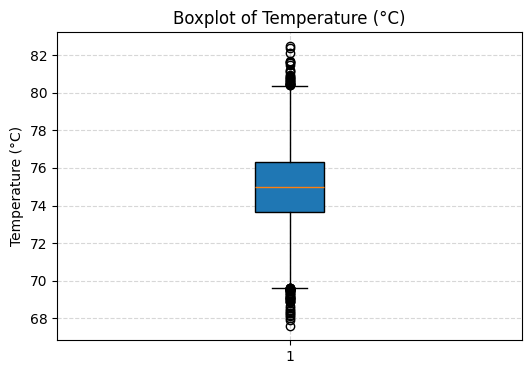

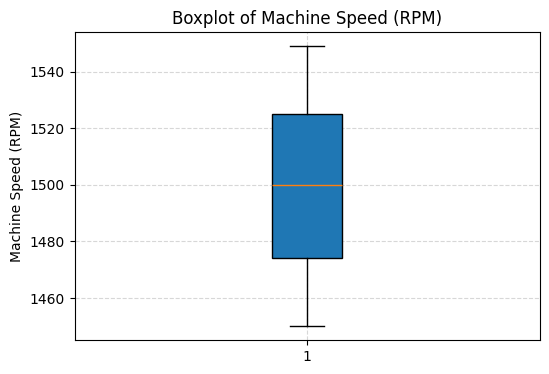

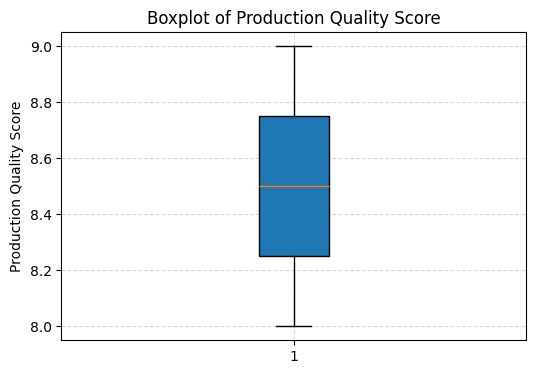

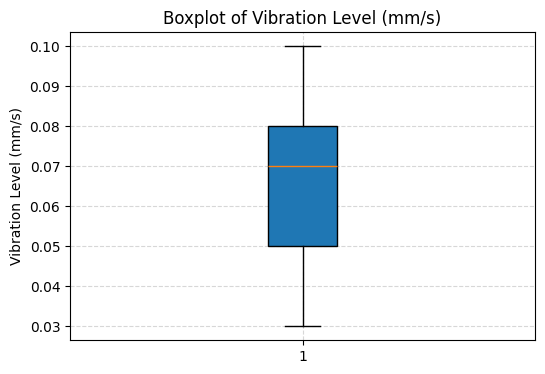

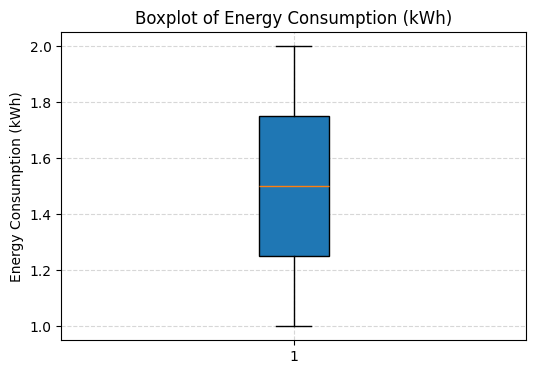

In [28]:
for col in NUMERIC_COLS:
    plt.figure(figsize=(6,4))
    plt.boxplot(df_clean[col].dropna(), vert=True, patch_artist=True)
    plt.title(f"Boxplot of {col}")
    plt.ylabel(col)
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.show()

##  Impact of Anomalies on Production Performance

 **Rows containing anomalies** have a **0% probability** of achieving optimal production conditions.  

 **Normal operating conditions** show a **9.73% success rate** in achieving optimal production conditions.

---

###  Key Insight

This result indicates a **strong negative association** between anomalies and production performance.

>  Anomalies are strongly linked with failure to achieve optimal production conditions, suggesting that abnormal machine behavior significantly reduces production efficiency.

---

In [29]:
# create testing dataset between Anomal and Optimal Conditions
df_testing = df_clean.copy()

# add anomaly flag
df_testing['is_anomaly'] = anomalies.any(axis=1).astype(int)

# check impact
result = df_testing.groupby('is_anomaly')['Optimal Conditions'].mean()
print(result)

is_anomaly
0   0.0973
1   0.0000
Name: Optimal Conditions, dtype: float64


## 8. Final Summary

In [30]:
print('=== CLEANED DATASET SUMMARY ===')
print(f'Shape : {df_clean.shape}')
print(f'Missing: {df_clean.isnull().sum().sum()} total')
print()
df.describe()

=== CLEANED DATASET SUMMARY ===
Shape : (10000, 7)
Missing: 0 total



,Timestamp,Temperature (°C),Machine Speed (RPM),Production Quality Score,Vibration Level (mm/s),Energy Consumption (kWh),Optimal Conditions
count,10000,10000.0000,10000.0000,10000.0000,10000.0000,10000.0000,10000.0000
mean,2025-04-04 19:19:30,74.9894,1499.5624,8.5008,0.0652,1.4991,0.0966
min,2025-04-01 08:00:00,67.5800,1450.0000,8.0000,0.0300,1.0000,0.0000
25%,2025-04-03 01:39:45,73.6600,1474.0000,8.2500,0.0500,1.2500,0.0000
50%,2025-04-04 19:19:30,75.0000,1500.0000,8.5000,0.0700,1.5000,0.0000
75%,2025-04-06 12:59:15,76.3400,1525.0000,8.7500,0.0800,1.7500,0.0000
max,2025-04-08 06:39:00,82.4700,1549.0000,9.0000,0.1000,2.0000,1.0000
std,NaN,1.9854,29.0597,0.2878,0.0206,0.2881,0.2954


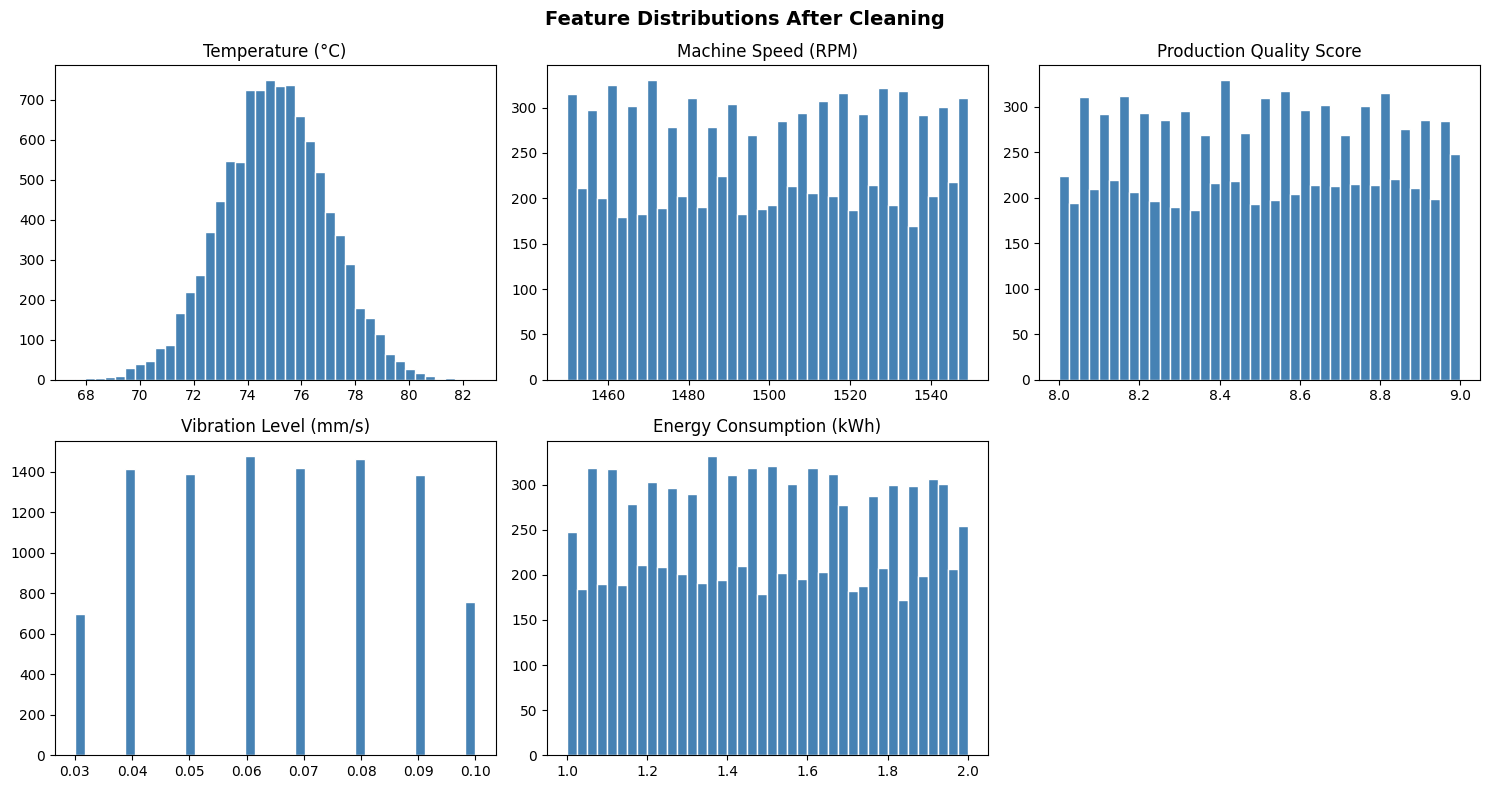

In [31]:
# Distribution plots after cleaning
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(NUMERIC_COLS):
    axes[i].hist(df_clean[col].dropna(), bins=40, color='steelblue', edgecolor='white')
    axes[i].set_title(col)
    axes[i].set_xlabel('')

# Hide unused subplot
axes[-1].set_visible(False)

plt.suptitle('Feature Distributions After Cleaning', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# Save cleaned dataset
#output_path = 'Manufacturing_dataset_cleaned.csv'
#df_clean.to_csv(output_path, index=False)
#print(f'✅ Cleaned dataset saved to: {output_path}')

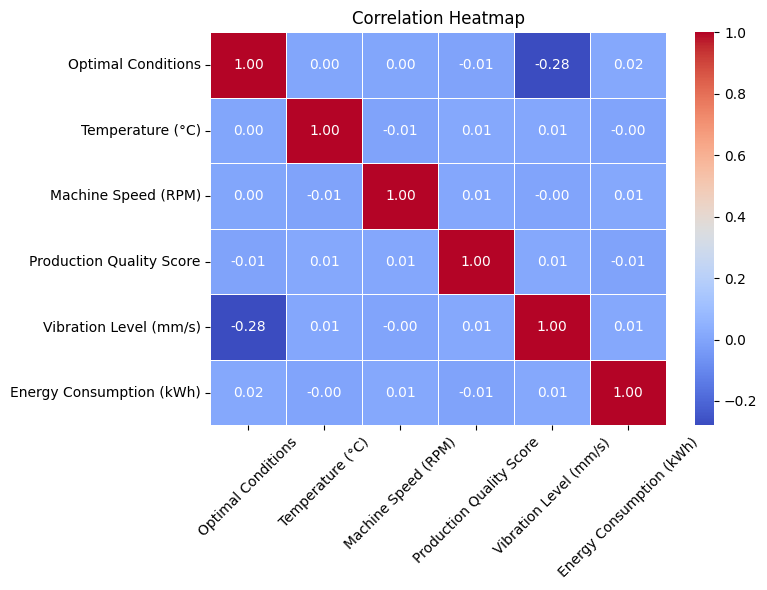

In [18]:
# Columns to include in correlation analysis
corr_cols = BINARY_COLS + NUMERIC_COLS

# Compute correlation matrix
corr_matrix = df[corr_cols].corr()

# Plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5
)

plt.title('Correlation Heatmap')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Hypothesises Testing

## Research Question

#### Do machine operational variables (temperature, speed, vibration, energy consumption) influence whether optimal production conditions are met?

---
### At a 5% significance level (α = 0.05):
## Null Hypothesis (H₀)

Machine operational variables (temperature, speed, vibration, and energy consumption) do **not** have a statistically significant effect on whether optimal production conditions are met.



## Alternative Hypothesis (H₁)

At least one machine operational variable (temperature, speed, vibration, or energy consumption) **has a statistically significant effect** on whether optimal production conditions are met.


---

##  Analysis Workflow (Logistic Regression)

- Step 1: Check Data Types 
- Step 2: Verify Dependent Variable Is Binary
- Step 3: Check Missing Values  
- Step 4: Check Class Balance
- Step 5: Fit logistic regression  
- Step 6: Conclusion 

## Justification for Using Logistic Regression Instead of ANOVA

ANOVA is not appropriate for this analysis because it requires a continuous dependent variable to compare group means across different categories. In this study, the dependent variable (Optimal Conditions) is binary (0 = not optimal, 1 = optimal), which violates the fundamental assumption of ANOVA.

Logistic regression is more suitable because it is specifically designed to model binary outcomes by estimating the probability of an event occurring. It also allows the inclusion of multiple continuous predictor variables (temperature, machine speed, vibration level, and energy consumption) to assess their individual and combined effects on the likelihood of achieving optimal conditions.

Furthermore, logistic regression provides interpretable statistical measures such as odds ratios, Wald z-tests, and p-values, which directly support hypothesis testing in this context.

Therefore, logistic regression is chosen over ANOVA because it correctly matches the binary nature of the dependent variable and provides a valid framework for testing the stated hypotheses.

### Step 1: Check Data Types
#### Result : Logistic regression is appropriate for this analysis because the dependent variable is binary (Optimal Conditions: 0/1), and the independent variables are continuous numeric measurements, which satisfy the key requirements for applying a binary logistic regression model.

In [37]:
df_clean.dtypes

Timestamp                   datetime64[ns]
Temperature (°C)                   float64
Machine Speed (RPM)                  int64
Production Quality Score           float64
Vibration Level (mm/s)             float64
Energy Consumption (kWh)           float64
Optimal Conditions                   int64
dtype: object

### Step 2. Verify Dependent Variable Is Binary
#### The dependent variable contains two categories (0 and 1), satisfying the requirement for binary logistic regression.
##### Confirms that the dependent variable contains only two classes (0 and 1), making it suitable for logistic regression.

In [34]:
print(df_clean['Optimal Conditions'].value_counts())

Optimal Conditions
0    9034
1     966
Name: count, dtype: int64


### Step 3: Check Missing Values
#### Missing values can bias regression estimates and must be checked before modelling.

In [35]:
# 1. Calculate the null counts for your specific columns
null_counts = df_clean[
    [
        'Optimal Conditions',
        'Temperature (°C)',
        'Machine Speed (RPM)',
        'Vibration Level (mm/s)',
        'Energy Consumption (kWh)'
    ]
].isnull().sum()

# 2. Check if the total number of nulls is greater than 0
if null_counts.sum() > 0:
    print("Error: There are null values in the dataset.")
    print(null_counts[null_counts > 0])  # Show which columns have the issue
    print("Cannot proceed to the next step.")
else:
    print("No null values found. Proceeding to the next step...")


No null values found. Proceeding to the next step...


### Step 4: Check Class Balance

#### The class distribution shows a significant imbalance, where 90.34% of observations are classified as non-optimal conditions (0), while only 9.66% represent optimal conditions (1).Although the dataset is imbalanced, logistic regression was still applied because the primary objective is hypothesis testing rather than predictive classification performance. Logistic regression remains valid for estimating the relationship between predictors and a binary outcome.

In [36]:
df_clean['Optimal Conditions'].value_counts(normalize=True)

Optimal Conditions
0   0.9034
1   0.0966
Name: proportion, dtype: float64

### Step 5: Fit logistic regression

In [33]:
from statsmodels.formula.api import logit

model = logit(
    '''
    Q("Optimal Conditions") ~
    Q("Temperature (°C)") +
    Q("Machine Speed (RPM)") +
    Q("Vibration Level (mm/s)") +
    Q("Energy Consumption (kWh)")
    ''',
    data=df_clean
).fit()

print(model.summary())

Optimization terminated successfully.
         Current function value: 0.274568
         Iterations 8
                              Logit Regression Results                             
Dep. Variable:     Q("Optimal Conditions")   No. Observations:                10000
Model:                               Logit   Df Residuals:                     9995
Method:                                MLE   Df Model:                            4
Date:                     Thu, 14 May 2026   Pseudo R-squ.:                  0.1353
Time:                             17:05:44   Log-Likelihood:                -2745.7
converged:                            True   LL-Null:                       -3175.5
Covariance Type:                 nonrobust   LLR p-value:                9.471e-185
                                    coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
Intercept                     

##  Conclusion (Logistic Regression Analysis)

The logistic regression model was statistically significant (LLR p-value < 0.001), indicating that the set of machine operational variables jointly influences optimal production conditions. The model explains approximately 13.53% of the variation in the outcome (Pseudo R² = 0.1353), which is reasonable for real-world industrial data.

At a 5% significance level:

- **Vibration Level (mm/s)** shows a strong negative and statistically significant effect (p < 0.001), indicating that higher vibration reduces the likelihood of optimal conditions.
- **Energy Consumption (kWh)** has a significant positive effect (p = 0.043), suggesting a slight increase in the probability of achieving optimal conditions.
- **Temperature (°C)** (p = 0.697) and **Machine Speed (RPM)** (p = 0.977) are not statistically significant predictors.

###  Final Decision

The null hypothesis (H₀) is rejected.  
At least one operational variable significantly affects optimal production conditions.

###  Key Insight

Vibration level is the most influential factor in the model, while energy consumption plays a secondary but significant role. Other variables show no measurable impact within this dataset.

### **Note**
Although Energy Consumption shows a near-zero correlation (r = 0.02) with Optimal Conditions, it becomes statistically significant in the logistic regression model (p = 0.043). This indicates that its effect is not evident in simple pairwise analysis but emerges when controlling for other operational variables. This suggests a weak but conditional relationship within the multivariate system.